In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../")

In [3]:
import glob
import joblib
import pandas as pd
#from pathlib import Path
import matplotlib.pyplot as plt

from phonetics import utils as u
from phonetics import phone_info as ph_i 
from phonetics import plots as plots

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
root = '/Users/tomasandrade/Documents/BSC/ICHOIR/datasets/pellizco_25122025/experiments'
experiment_path = f'{root}/maria_3d/feat_768d'
feat_path = f'{experiment_path}/feat_768d_layer_12.csv'

In [5]:
df_anotated = pd.read_csv(feat_path, index_col=0)

phoneme_order = list(df_anotated['phone_base'].value_counts().keys())
rank = {p: i for i, p in enumerate(phoneme_order)}

df_anotated = (
    df_anotated
    .assign(_phoneme_rank=df_anotated["phone_base"].map(rank))
    .sort_values(
        ["_phoneme_rank", "duration"],
        kind="mergesort"
    )
    .drop(columns="_phoneme_rank")
    .reset_index(drop=True)
)

/var/folders/8k/_0xh01hd7y9bl_vjjlwxqtjr0000gn/T/ipykernel_62070/679306711.py:1: DtypeWarning: Columns (769) have mixed types. Specify dtype option on import or set low_memory=False.
  df_anotated = pd.read_csv(feat_path, index_col=0)


<Axes: xlabel='phone_base'>

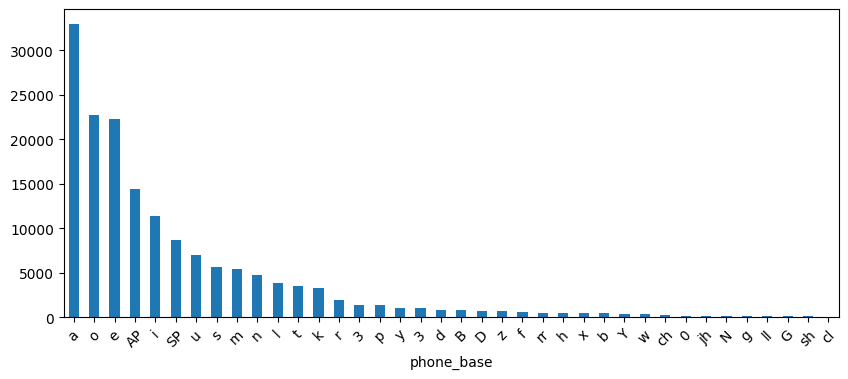

In [6]:
plt.figure(figsize=(10,4))
df_anotated['phone_base'].value_counts().plot.bar(rot = 45)

In [7]:
len(df_anotated['phone_base'])*0.02/60

53.20033333333333

In [8]:
df_anotated['song'].unique()

array(['ES_el_dia_que_naci_yo', 'ES_tu_que_vienes_a_rondarme',
       'CA_la_pastoreta', 'ES_milagro', 'ES_ventura2',
       'ES_lucero_de_la_maniana', 'ES_hildegart', 'CA_meteorit_ferit',
       'ES_quien_me_ama', 'CA_mabravasa', 'ES_volver_a_los_17',
       'CA_viola', 'ES_ventura', 'CA_impro', 'ES_negro_infinito',
       'CA_no_he_desitjat', 'CA_sol_solet', 'ES_jota', 'ES_galapaguito',
       'CA_impro2', 'ES_que_lejos_estoy_de_la_tierra', 'CA_xiqueta_meuna',
       'CA_impro3', 'ES_tras_de_ti', 'CA_sibi_la',
       'ES_la_sobra_de_la_luz', 'CA_un_gat_petit_tv3', 'CA_sol_solet-2',
       'ES_yo_vi_secarse_una_jara', 'CA_tu_saps'], dtype=object)

In [9]:
umap2 = u.train_umap(
        df_anotated,
        exclude_phones = ['SP'],
        n_components=2, 
        n_neighbors=100, 
        min_dist=0.1,
        n_jobs = 1,
        save_model = False,
        folder = None)

df_proj2d = u.make_proj_anotated_feat_df(df_anotated, 
                                        umap2,
                                        save_df = False,
                                        folder = None)

Training UMAP with parameters n_components : 2, n_neighbors 100, min_dist : 0.1, n_jobs : 1
Finished umap traning. Training time: 341.1342468261719


In [10]:
unique_phones = [k for k in df_proj2d['phone_base'].value_counts().keys() if k != 'SP']

Making a 2d plot


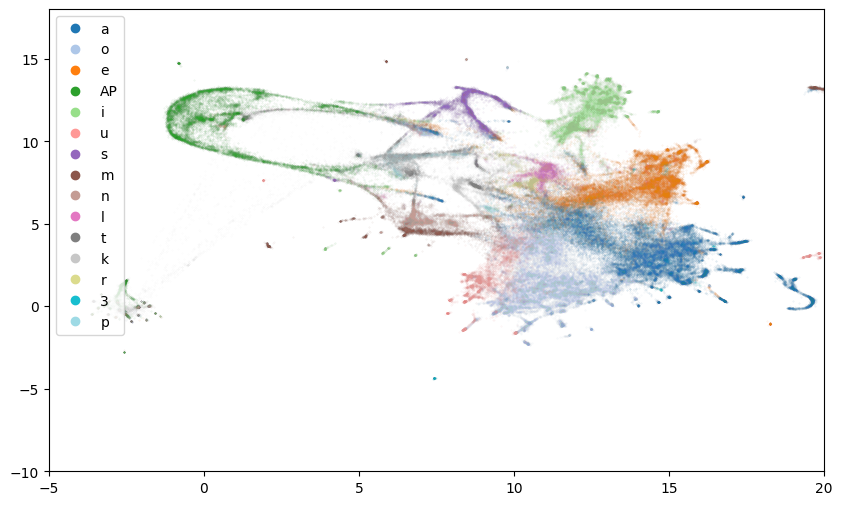

In [11]:
plots.make_tagged_LS_plot(df_proj2d,
            phones = unique_phones[:15],
            alpha = 0.1, 
            s = 0.1,
            show_global=True,
            xlim = [ -5, 20],
            ylim = [-10, 18])

In [12]:
p_root = '/Users/tomasandrade/Documents/BSC/ICHOIR/datasets/plants/feat'
p_file1 = f'{p_root}/feats_zz-touch-processed.csv'
p_file2 = f'{p_root}/feats_zz-touch-processed_output.csv'

In [14]:
def proj_song(feat_file):
    df_song_feat = pd.read_csv(feat_file, index_col=0)
    X = df_song_feat.values
    X_projected = umap2.transform(X)

    df_song_proj = pd.DataFrame(data = X_projected, columns = ['x', 'y'])

    return df_song_proj

In [15]:
df_song_proj_1 = proj_song(p_file1)
df_song_proj_2 = proj_song(p_file2)

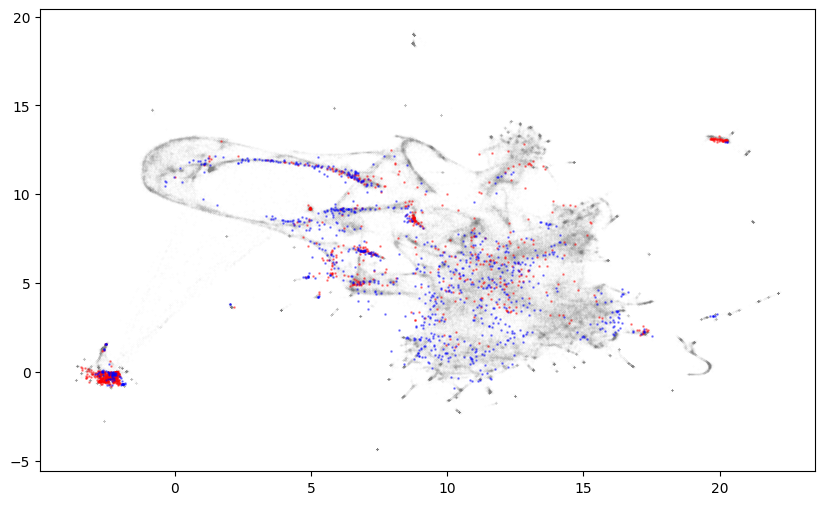

In [19]:
fig = plt.figure(figsize=(10,6)) 
ax = fig.add_subplot(111)
ax.scatter(df_proj2d['x'], df_proj2d['y'],
            alpha=0.05,
            s = 0.05, 
            color= 'grey')

ax.scatter(df_song_proj_1['x'], df_song_proj_1['y'],
            alpha=0.4,
            s = 0.8, 
            color= 'red')

ax.scatter(df_song_proj_2['x'], df_song_proj_2['y'],
            alpha=0.4,
            s = 0.8, 
            color= 'blue')

In [20]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

In [21]:
X_full_values = df_anotated.drop(columns=['phone_base', 'duration', 'song']).to_numpy()

In [22]:
# Build KD-tree from df1 points
tree = cKDTree(X_full_values)

In [23]:
# df1 columns: x, y, tag (and maybe others)
# df2 columns: x, y

df_song_feat = pd.read_csv(p_file1, index_col=0)

# Query nearest df1 point for each df2 point
dist, idx = tree.query(df_song_feat.to_numpy(), k=1)  # k=1 = nearest

# Assign tag (and optionally distance / matched df1 index)
df2_tagged = df_song_feat.copy()
df2_tagged['phone_base'] = df_anotated.iloc[idx]['phone_base'].to_numpy()

df2_tagged['nn_distance'] = dist
df2_tagged['nn_df1_index'] = df_anotated.index.to_numpy()[idx]  # keeps original df1 index

In [24]:
df2_tagged_no_sil = df2_tagged[~df2_tagged['phone_base'].isin(['AP', 'SP'])]

In [25]:
collapsed = df2_tagged_no_sil.loc[
    df2_tagged_no_sil['phone_base'].ne(df2_tagged_no_sil['phone_base'].shift())
].reset_index(drop=True)

In [26]:
print(list(collapsed['phone_base']))

['m', 'h', 'z', 'n', 'cl', 'm', 'n', 'B', 'a', 'B', 'a', 'u', 'B', 'o', 'e', 'a', 'rr', 'e', 'a', 'l', 'e', 'a', 'l', 'n', 'k', 'z', 'n', 'h', 'o', '3', 'o', 'a', 'o', 'k', 'Y', 'k', 'cl', 's', 'cl', 'e', 'n', 'a', 'i', 'e', 'z', 'f', 'o', 'f', 'u', 'o', 'u', 'm', 'a', 'm', 'r', 'a', 'cl', 'B', 'cl', 'z', 'f', 'z', 'h', 'a', 'x', 'z', 'h', 'z', 'n', 'a', 'd', 'n', 'B', 'a', 'd', 'z', 'f', 's', 'Y', 't', 'a', 'e', 'l', 'a', 'n', 'm', 'n', 'd', 'o', 3, 'a', 'z', 'e', 'a', 'o', 'a', 'o', 'a', 'm', 'a', 'cl', 't', 'n', 'a', 'n', 'a', 'm', 'o', 'm', 'u', 'e', 'z', 'm', 'z', 's', 'i', 'rr', 'a', 'y', 'cl', 'm', 'k', 'o', 'h', 'cl', 'k', 'm', 'e', 'B', 'd', 'n', 'cl', 'a', 'o', 'a', 'l', 'a', '3', 'h', 'Y', 'cl', 'h', 'e', 'B', 'Y', 't', 'cl', 'h', 'l', 'n', 'x', 'z', 'rr', 's', 'cl', 'r', 'h', 'a', 'k', 'cl', 'k', 'z', 'a', 'h', 'a', 'l', 'i', 'o', 'a', 'B', 'l', 'a', 'e', 'l', 'a', 'r', 'z', 'x', 's', 't', 'e', 'D', 'e', 'z', 'cl', 't', 'k', 's', 'rr', 'h', 'a', 'e', 'l', 'e', 'B', 'b', 'l'

In [27]:
df_song_2d_proximity = df_proj2d.iloc[df2_tagged['nn_df1_index']][['x', 'y', 'phone_base']]

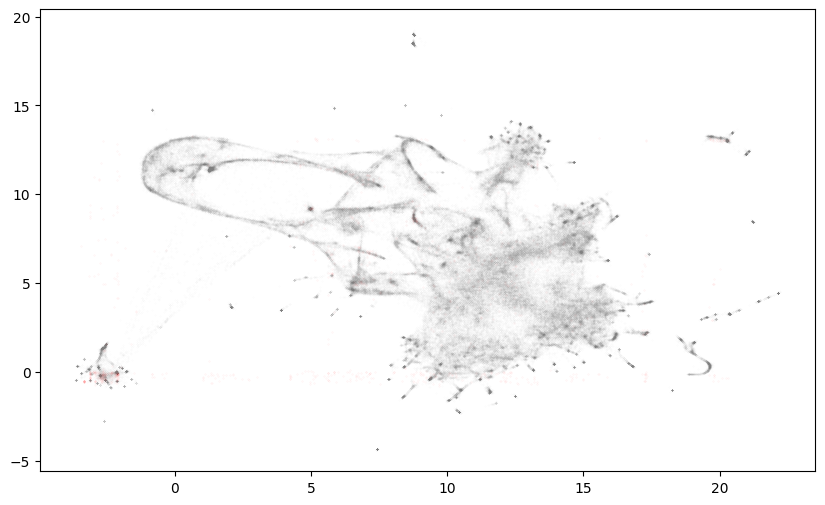

In [28]:
fig = plt.figure(figsize=(10,6)) 
ax = fig.add_subplot(111)
ax.scatter(df_proj2d['x'], df_proj2d['y'],
            alpha=0.05,
            s = 0.05, 
            color= 'grey')

ax.scatter(df_song_2d_proximity['x'], df_song_proj_1['y'],
            alpha=0.1,
            s = 0.05, 
            color= 'red')

<Axes: xlabel='phone_base'>

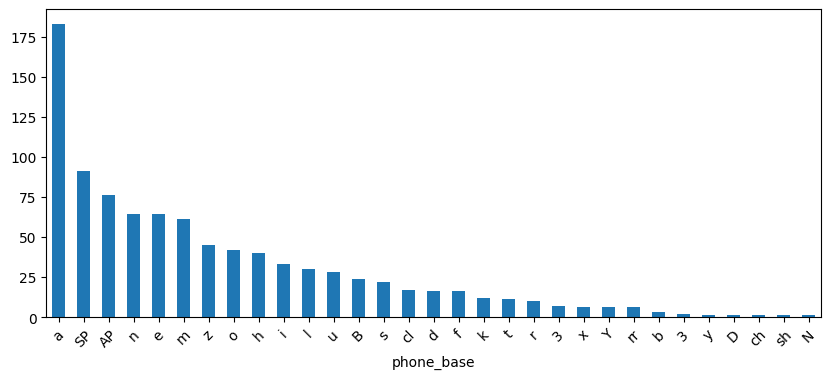

In [29]:
plt.figure(figsize=(10,4))
df2_tagged['phone_base'].value_counts().plot.bar(rot = 45)